# Fake vs Real News

- EDA with visuals and quality checks
- Duplicate handling
- Time-based train/test split
- TF-IDF baseline model
- DistilBERT fine-tuning
- Domain-adversarial experiment

Each code block has a short note above it describing what it does.

Dataset: Clément Bisaillon, *Fake and Real News Dataset* (Kaggle): https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset/data


## 1) Environment Setup

Import libraries for data loading, plotting, feature engineering, and modeling.


In [64]:
# Standard library utilities for text cleanup, hashing, and file paths.
import re
import hashlib
from pathlib import Path

# Core data and plotting stack for EDA and diagnostics.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sparse matrix helper for combining multiple TF-IDF feature spaces.
from scipy.sparse import hstack

# Feature extraction and baseline linear model.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluation metrics used throughout model comparison.
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

# Calibration and dense projection utilities for analyses.
from sklearn.calibration import calibration_curve
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

# Seeded randomness keeps train/test behavior reproducible across runs.
np.random.seed(RANDOM_STATE)


## 2) Data Paths and Loading

Load `Fake.csv` and `True.csv`, then add labels (`fake` / `real`).


In [65]:
BASE_DIR = Path.cwd()

# In Colab, uploaded files are commonly placed under /content/sample_data.
candidate_dirs = [
    BASE_DIR / 'sample_data',
    BASE_DIR / 'data',
    BASE_DIR.parent / 'data',
    Path('/content/sample_data'),
    Path('/content/data'),
    Path('/content/drive/MyDrive/sample_data'),
    Path('/content/drive/MyDrive/data'),
]

DATA_DIR = None
for d in candidate_dirs:
    if (d / 'Fake.csv').exists() and (d / 'True.csv').exists():
        DATA_DIR = d
        break

assert DATA_DIR is not None, (
    "Could not find Fake.csv and True.csv. Place both files in sample_data/ or data/."
)

FAKE_PATH = DATA_DIR / 'Fake.csv'
TRUE_PATH = DATA_DIR / 'True.csv'

print(f'Using data directory: {DATA_DIR}')

# Add class labels at load time so both files can be concatenated.
fake_df = pd.read_csv(FAKE_PATH).assign(label='fake')
real_df = pd.read_csv(TRUE_PATH).assign(label='real')

df = pd.concat([fake_df, real_df], ignore_index=True)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(5)


Using data directory: /Users/justin/CSC466/Fake-News/data
Shape: (44898, 5)
Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake


## 3) Data Quality Inspection (Missing Values, Duplicates, Class Balance)

Check missing values, duplicates, and class balance before modeling.


In [66]:
missing = df.isna().sum().sort_values(ascending=False)
class_counts = df['label'].value_counts()

duplicates_all = df.duplicated().sum()
duplicates_title_text = df.duplicated(subset=['title', 'text']).sum()

# nunique per (title, text) checks if the same story text appears with mixed labels.
conflicting = (
    df.groupby(['title', 'text'])['label']
      .nunique()
      .reset_index(name='n_labels')
)
conflicting_pairs = (conflicting['n_labels'] > 1).sum()

summary = pd.DataFrame({
    'metric': [
        'rows', 'columns', 'missing_total',
        'duplicates_all_columns', 'duplicates_title_text', 'title_text_conflicting_labels'
    ],
    'value': [
        len(df), df.shape[1], int(missing.sum()),
        int(duplicates_all), int(duplicates_title_text), int(conflicting_pairs)
    ]
})

display(summary)
display(class_counts.to_frame('count'))
display((class_counts / class_counts.sum()).rename('pct'))
display(missing.to_frame('missing_values'))


,metric,value
0,rows,44898
1,columns,5
2,missing_total,0
3,duplicates_all_columns,209
4,duplicates_title_text,5793
5,title_text_conflicting_labels,0


,count
label,
fake,23481
real,21417


label
fake    0.522985
real    0.477015
Name: pct, dtype: float64

,missing_values
title,0
text,0
subject,0
date,0
label,0


## 4) Parse Dates and Build Core EDA Features

Parse dates and create simple features: article length, title length, and unique word count.


In [67]:
def parse_mixed_dates(series: pd.Series) -> pd.Series:
    # format='mixed' lets pandas infer multiple date formats in one column.
    return pd.to_datetime(series.astype(str).str.strip(), errors='coerce', format='mixed')

eda_df = df.copy()
eda_df['title'] = eda_df['title'].fillna('')
eda_df['text'] = eda_df['text'].fillna('')
eda_df['parsed_date'] = parse_mixed_dates(eda_df['date'])
eda_df['year'] = eda_df['parsed_date'].dt.year
eda_df['month'] = eda_df['parsed_date'].dt.month

eda_df['text_word_count'] = eda_df['text'].str.split().str.len()
eda_df['title_word_count'] = eda_df['title'].str.split().str.len()
# Convert token list to a set to measure lexical diversity per article.
eda_df['unique_word_count'] = eda_df['text'].str.lower().str.split().apply(lambda x: len(set(x)) if isinstance(x, list) else 0)

print('Parsed dates:', eda_df['parsed_date'].notna().sum())
print('Unparsed dates:', eda_df['parsed_date'].isna().sum())
eda_df[['label', 'date', 'parsed_date', 'text_word_count', 'title_word_count']].head()


Parsed dates: 44888
Unparsed dates: 10


,label,date,parsed_date,text_word_count,title_word_count
0,fake,"December 31, 2017",2017-12-31,495,12
1,fake,"December 31, 2017",2017-12-31,305,8
2,fake,"December 30, 2017",2017-12-30,580,15
3,fake,"December 29, 2017",2017-12-29,444,14
4,fake,"December 25, 2017",2017-12-25,420,11


## 5) EDA Graphs: Class Balance and Length Distributions

To visualize class balance and text/title length distributions.

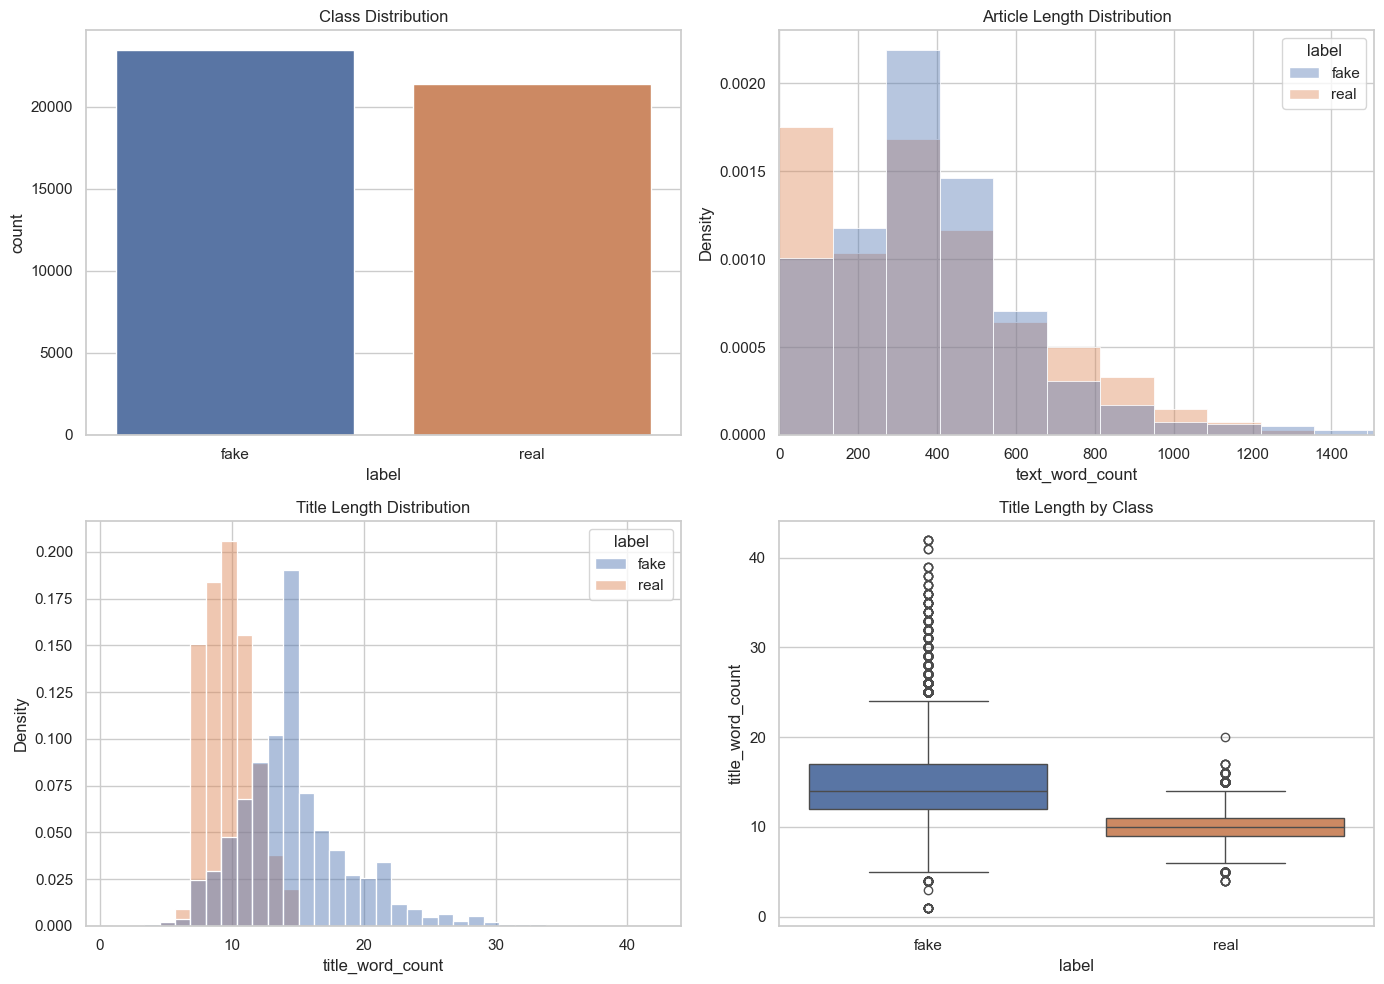

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=eda_df, x='label', hue='label', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Class Distribution')

sns.histplot(data=eda_df, x='text_word_count', hue='label', bins=60, stat='density', common_norm=False, alpha=0.4, ax=axes[0, 1])
axes[0, 1].set_title('Article Length Distribution')
# Trim the x-axis to the 99th percentile so extreme outliers do not flatten the plot.
axes[0, 1].set_xlim(0, eda_df['text_word_count'].quantile(0.99))

sns.histplot(data=eda_df, x='title_word_count', hue='label', bins=35, stat='density', common_norm=False, alpha=0.45, ax=axes[1, 0])
axes[1, 0].set_title('Title Length Distribution')

sns.boxplot(data=eda_df, x='label', y='title_word_count', hue='label', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Title Length by Class')

plt.tight_layout()
plt.show()


## 6) EDA Graphs: Subject and Time Trends

Inspect subject counts and year trends by class to spot strong shortcuts or time shifts.


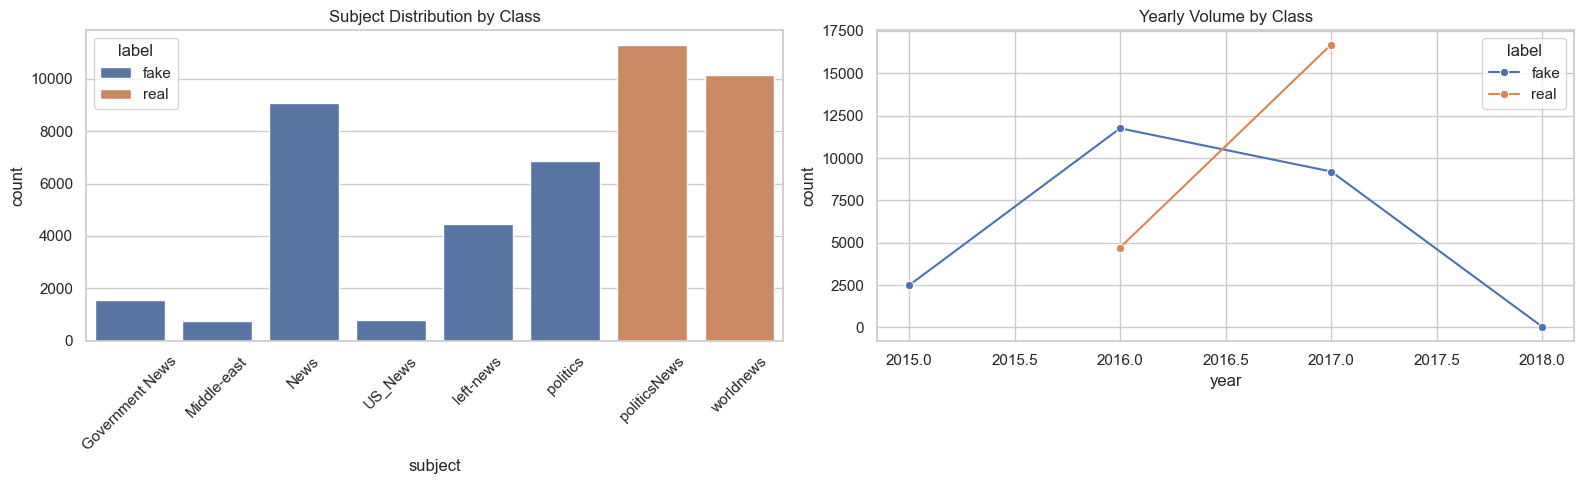

label,fake,real
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4459,0
politics,6841,0
politicsNews,0,11272
worldnews,0,10145


In [69]:
subject_counts = (
    eda_df.groupby(['subject', 'label']).size().reset_index(name='count')
)

year_counts = (
    eda_df.dropna(subset=['year']).groupby(['year', 'label']).size().reset_index(name='count')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=subject_counts, x='subject', y='count', hue='label', ax=axes[0])
axes[0].set_title('Subject Distribution by Class')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=year_counts, x='year', y='count', hue='label', marker='o', ax=axes[1])
axes[1].set_title('Yearly Volume by Class')

plt.tight_layout()
plt.show()

# Crosstab is easier to inspect when checking whether subject leaks the class label.
subject_pivot = pd.crosstab(eda_df['subject'], eda_df['label'])
display(subject_pivot)


## 7) Text Normalization, Source-Token Removal, and Group IDs

Normalize text, remove obvious source boilerplate, and create a deterministic `group_id` hash from `title + text` so duplicate stories stay in one split.


In [70]:
def normalize_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http[s]?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Patterns that can leak source/platform identity rather than news veracity.
SOURCE_BIAS_PATTERNS = [
    r'\breuters\b',
    r'\bwashington reuters\b',
    r'\bfeatured image\b',
    r'\bpic twitter\b',
    r'\btwitter com\b',
    r'\bimage via\b',
]

def remove_source_boilerplate(text: str) -> str:
    text = normalize_text(text)
    for pattern in SOURCE_BIAS_PATTERNS:
        text = re.sub(pattern, ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

model_df = eda_df.copy()
model_df['full_text'] = model_df['title'].astype(str) + ' ' + model_df['text'].astype(str)

# Used for duplicate grouping / split control.
model_df['normalized_full_text'] = model_df['full_text'].map(normalize_text)
# Hashing creates a stable group key from text so near-identical stories can stay together.
model_df['group_id'] = model_df['normalized_full_text'].map(
    lambda x: hashlib.sha1(x.encode('utf-8')).hexdigest()
)

# Used for modeling to reduce source/style shortcuts.
model_df['model_text'] = model_df['full_text'].map(remove_source_boilerplate)

before_rows = len(model_df)
model_df = (
    model_df.sort_values('parsed_date')
            .drop_duplicates(subset=['group_id', 'label'], keep='first')
            .copy()
)
after_rows = len(model_df)

print(f'Rows before dedup: {before_rows:,}')
print(f'Rows after dedup:  {after_rows:,}')
print(f'Removed:           {before_rows - after_rows:,}')

# Quick check: how often source cue words still appear after cleaning.
leftover_cues = model_df['model_text'].str.contains(r'\breuters\b|\bfeatured image\b|\bpic twitter\b', regex=True).mean()
print(f'Rows still containing key source cues after cleaning: {leftover_cues:.2%}')


Rows before dedup: 44,898
Rows after dedup:  38,827
Removed:           6,071
Rows still containing key source cues after cleaning: 0.00%


## 8) Time-Based Train/Test Split

We split by year at the group level:
- train groups with earliest year `<= 2016`
- test groups with earliest year `>= 2017`

This keeps duplicate groups from crossing splits and tests on later data.


In [71]:
split_df = model_df.dropna(subset=['parsed_date']).copy()

# Group-level metadata so duplicate stories stay in one split.
group_meta = split_df.groupby('group_id').agg(
    group_date=('parsed_date', 'min'),
)
group_meta['group_year'] = group_meta['group_date'].dt.year

SPLIT_STRATEGY = 'year_holdout'  # options: 'year_holdout' or 'quantile_time'
TRAIN_MAX_YEAR = 2016
TEST_MIN_YEAR = 2017

if SPLIT_STRATEGY == 'year_holdout':
    # Time split keeps later stories out of training.
    train_groups = group_meta.index[group_meta['group_year'] <= TRAIN_MAX_YEAR]
    test_groups = group_meta.index[group_meta['group_year'] >= TEST_MIN_YEAR]
    print(f'Split strategy: strict year holdout (train <= {TRAIN_MAX_YEAR}, test >= {TEST_MIN_YEAR})')
else:
    cutoff_date = group_meta['group_date'].quantile(0.80)
    train_groups = group_meta.index[group_meta['group_date'] <= cutoff_date]
    test_groups = group_meta.index[group_meta['group_date'] > cutoff_date]
    print(f'Split strategy: quantile time split (80/20), cutoff={cutoff_date.date()}')

train_df = split_df[split_df['group_id'].isin(train_groups)].copy()
test_df = split_df[split_df['group_id'].isin(test_groups)].copy()

assert len(train_df) > 0 and len(test_df) > 0, 'Empty train or test split. Adjust split settings.'

print('Train rows :', len(train_df))
print('Test rows  :', len(test_df))
print('Train year range:', int(train_df['year'].min()), '-', int(train_df['year'].max()))
print('Test year range :', int(test_df['year'].min()), '-', int(test_df['year'].max()))

print('\nTrain class distribution:')
print(train_df['label'].value_counts(normalize=True).round(3))
print('\nTest class distribution:')
print(test_df['label'].value_counts(normalize=True).round(3))


Split strategy: strict year holdout (train <= 2016, test >= 2017)
Train rows : 15785
Test rows  : 23040
Train year range: 2015 - 2016
Test year range : 2017 - 2018

Train class distribution:
label
fake    0.702
real    0.298
Name: proportion, dtype: float64

Test class distribution:
label
real    0.704
fake    0.296
Name: proportion, dtype: float64


## 9) Split Integrity Checks

Confirm that no `group_id` appears in both train and test.


In [72]:
train_groups_set = set(train_df['group_id'])
test_groups_set = set(test_df['group_id'])
overlap = train_groups_set.intersection(test_groups_set)

print('Overlapping groups:', len(overlap))
# Any overlap here means the same story group appears in both splits.
assert len(overlap) == 0, 'Split overlap detected: overlapping group_id in train and test.'
print('Split overlap check passed.')


Overlapping groups: 0
Split overlap check passed.


## 10) Feature Engineering for the Linear Baseline (TF-IDF)

Build TF-IDF features from `model_text` using:
- word n-grams `(1, 2)`
- character n-grams `(3, 5)`

This is a fast, strong baseline for text classification.


In [73]:
X_train_text = train_df['model_text'].astype(str)
X_test_text = test_df['model_text'].astype(str)

y_train = (train_df['label'] == 'fake').astype(int).values
y_test = (test_df['label'] == 'fake').astype(int).values

word_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=40_000,
    min_df=3,
    stop_words='english',
    strip_accents='unicode',
    sublinear_tf=True,
)

char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=50_000,
    min_df=3,
    sublinear_tf=True,
)

Xw_train = word_tfidf.fit_transform(X_train_text)
Xw_test = word_tfidf.transform(X_test_text)
Xc_train = char_tfidf.fit_transform(X_train_text)
Xc_test = char_tfidf.transform(X_test_text)

# Combine word and character sparse features to capture both semantics and style.
X_train = hstack([Xw_train, Xc_train]).tocsr()
X_test = hstack([Xw_test, Xc_test]).tocsr()

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)


X_train shape: (15785, 90000)
X_test shape : (23040, 90000)


## 11) Train the Linear Baseline

Train Logistic Regression on TF-IDF features.


In [74]:
linear_clf = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)

linear_clf.fit(X_train, y_train)

linear_test_proba = linear_clf.predict_proba(X_test)[:, 1]
linear_test_pred = (linear_test_proba >= 0.50).astype(int)

linear_metrics = {
    'f1': f1_score(y_test, linear_test_pred, average='binary', pos_label=1),
    'roc_auc': roc_auc_score(y_test, linear_test_proba),
    'pr_auc': average_precision_score(y_test, linear_test_proba),
}

linear_metrics


{'f1': 0.9015474018514764,
 'roc_auc': 0.992307965499269,
 'pr_auc': 0.9855538674620503}

## 12) Baseline Results and Error Analysis

Evaluate with confusion matrix and core metrics.

- `F1` summarizes precision/recall for the fake class.
- `ROC-AUC` and `PR-AUC` summarize score quality across thresholds.
- Error inspection shows where predictions fail.


### Metric Labels (Plain English)

- **F1 (higher is better):** Balance of catching fake stories and avoiding false alarms.
- **ROC-AUC (higher is better):** Chance a random fake story gets a higher score than a random real story.
- **PR-AUC (higher is better):** How well precision stays high while recall increases for fake stories.

Rule of thumb: closer to `1.0` is better; `0.5` is random for AUC metrics.


Linear baseline metrics (clear labels):
- F1 (higher is better): 0.9015
- ROC-AUC (higher is better): 0.9923
- PR-AUC (higher is better): 0.9856

Classification report:
              precision    recall  f1-score   support

        real       0.99      0.92      0.95     16228
        fake       0.84      0.98      0.90      6812

    accuracy                           0.94     23040
   macro avg       0.91      0.95      0.93     23040
weighted avg       0.94      0.94      0.94     23040



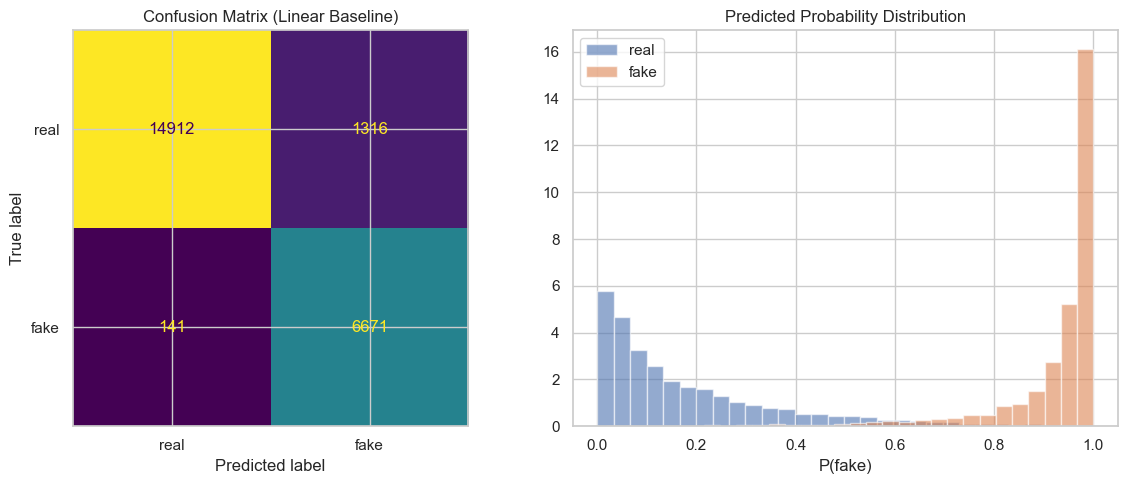

In [75]:
print('Linear baseline metrics (clear labels):')
print(f"- F1 (higher is better): {linear_metrics['f1']:.4f}")
print(f"- ROC-AUC (higher is better): {linear_metrics['roc_auc']:.4f}")
print(f"- PR-AUC (higher is better): {linear_metrics['pr_auc']:.4f}")

print('\nClassification report:')
print(classification_report(y_test, linear_test_pred, target_names=['real', 'fake']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, linear_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['real', 'fake']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Linear Baseline)')

# Side-by-side score histograms show how well predicted probabilities separate classes.
axes[1].hist(linear_test_proba[y_test == 0], bins=30, alpha=0.6, label='real', density=True)
axes[1].hist(linear_test_proba[y_test == 1], bins=30, alpha=0.6, label='fake', density=True)
axes[1].set_title('Predicted Probability Distribution')
axes[1].set_xlabel('P(fake)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 13) Probability Reliability Check

Check whether predicted probabilities match actual frequencies. A model can rank well but still output overconfident or underconfident probabilities.


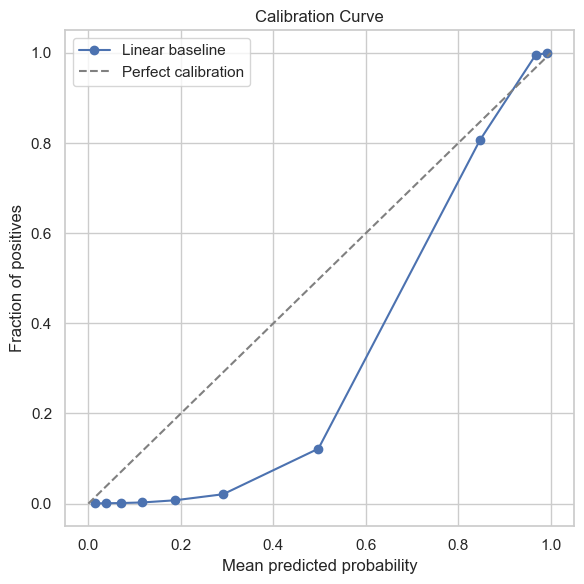

In [76]:
prob_true, prob_pred = calibration_curve(y_test, linear_test_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Linear baseline')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.tight_layout()
plt.show()


## 14) DistilBERT Model

DistilBERT uses contextual text representations and can outperform linear models on nuanced language.


In [77]:
# Install if your environment is missing packages:
%pip install -q torch transformers datasets accelerate

# Dependency check for transformer and DANN sections.
import importlib.util
required = ['torch', 'transformers', 'datasets', 'accelerate']
# find_spec checks availability without importing large packages.
missing = [p for p in required if importlib.util.find_spec(p) is None]
assert not missing, f'Missing packages: {missing}. Install them and rerun this cell.'
print('All required packages are available.')

Note: you may need to restart the kernel to use updated packages.
All required packages are available.


## 15) DistilBERT Fine-Tuning Code

Fine-tune `distilbert-base-uncased` on train data and evaluate on test data. We subsample to keep runtime manageable on CPU.


In [78]:
# Hugging Face dataset wrapper and trainer components for fine-tuning DistilBERT.
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

bert_train = train_df[['full_text', 'label']].copy()
bert_test = test_df[['full_text', 'label']].copy()

# Subsampling keeps the run tractable while preserving enough data for comparison.
bert_train = bert_train.sample(min(len(bert_train), 20000), random_state=RANDOM_STATE)
bert_test = bert_test.sample(min(len(bert_test), 5000), random_state=RANDOM_STATE)

label_map = {'real': 0, 'fake': 1}
bert_train['y'] = bert_train['label'].map(label_map)
bert_test['y'] = bert_test['label'].map(label_map)

train_ds = Dataset.from_pandas(bert_train[['full_text', 'y']].rename(columns={'full_text': 'text', 'y': 'label'}))
test_ds = Dataset.from_pandas(bert_test[['full_text', 'y']].rename(columns={'full_text': 'text', 'y': 'label'}))

model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=256)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds = train_ds.remove_columns(['text'])
test_ds = test_ds.remove_columns(['text'])
train_ds.set_format('torch')
test_ds.set_format('torch')

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

common_args = dict(
    output_dir=str(BASE_DIR / 'outputs' / 'bert_run'),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    save_strategy='no',
    logging_steps=100,
    report_to='none',
    disable_tqdm=True,
    seed=RANDOM_STATE,
)
try:
    # transformers renamed this kwarg in different versions; this keeps compatibility.
    args = TrainingArguments(eval_strategy='epoch', **common_args)
except TypeError:
    args = TrainingArguments(evaluation_strategy='epoch', **common_args)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits)
    labels = np.asarray(labels)
    # Stable softmax: subtract row-wise max before exp to reduce overflow risk.
    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp_logits[:, 1] / exp_logits.sum(axis=1)
    preds = (probs >= 0.5).astype(int)
    return {
        'f1': f1_score(labels, preds, average='binary', pos_label=1),
        'roc_auc': roc_auc_score(labels, probs),
        'pr_auc': average_precision_score(labels, probs),
    }

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer.train()
bert_eval = trainer.evaluate()
print(bert_eval)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4922.20it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/justin/CSC466/Fake-News/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not suppo

{'loss': '0.1673', 'grad_norm': '0.05331', 'learning_rate': '1.95e-05', 'epoch': '0.05066'}
{'loss': '0.02824', 'grad_norm': '0.0198', 'learning_rate': '1.899e-05', 'epoch': '0.1013'}
{'loss': '0.004055', 'grad_norm': '0.01141', 'learning_rate': '1.849e-05', 'epoch': '0.152'}
{'loss': '0.01789', 'grad_norm': '0.008542', 'learning_rate': '1.798e-05', 'epoch': '0.2026'}
{'loss': '0.02832', 'grad_norm': '0.008157', 'learning_rate': '1.747e-05', 'epoch': '0.2533'}
{'loss': '0.01192', 'grad_norm': '0.006605', 'learning_rate': '1.697e-05', 'epoch': '0.304'}
{'loss': '0.0002859', 'grad_norm': '0.004398', 'learning_rate': '1.646e-05', 'epoch': '0.3546'}
{'loss': '0.01187', 'grad_norm': '0.006212', 'learning_rate': '1.595e-05', 'epoch': '0.4053'}
{'loss': '0.006761', 'grad_norm': '0.004312', 'learning_rate': '1.545e-05', 'epoch': '0.4559'}
{'loss': '0.01043', 'grad_norm': '0.004785', 'learning_rate': '1.494e-05', 'epoch': '0.5066'}
{'loss': '0.0002352', 'grad_norm': '0.002726', 'learning_rate':

/Users/justin/CSC466/Fake-News/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '8.346e-05', 'grad_norm': '0.00294', 'learning_rate': '9.873e-06', 'epoch': '1.013'}
{'loss': '7.496e-05', 'grad_norm': '0.001562', 'learning_rate': '9.367e-06', 'epoch': '1.064'}
{'loss': '5.778e-05', 'grad_norm': '0.001315', 'learning_rate': '8.86e-06', 'epoch': '1.114'}
{'loss': '4.833e-05', 'grad_norm': '0.001143', 'learning_rate': '8.354e-06', 'epoch': '1.165'}
{'loss': '4.587e-05', 'grad_norm': '0.001026', 'learning_rate': '7.847e-06', 'epoch': '1.216'}
{'loss': '3.997e-05', 'grad_norm': '0.0008865', 'learning_rate': '7.34e-06', 'epoch': '1.266'}
{'loss': '3.852e-05', 'grad_norm': '0.0006921', 'learning_rate': '6.834e-06', 'epoch': '1.317'}
{'loss': '3.547e-05', 'grad_norm': '0.0009916', 'learning_rate': '6.327e-06', 'epoch': '1.368'}
{'loss': '3.788e-05', 'grad_norm': '0.002437', 'learning_rate': '5.821e-06', 'epoch': '1.418'}
{'loss': '3.396e-05', 'grad_norm': '0.0006298', 'learning_rate': '5.314e-06', 'epoch': '1.469'}
{'loss': '3.33e-05', 'grad_norm': '0.0007254', 'l

/Users/justin/CSC466/Fake-News/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.03017', 'eval_f1': '0.9943', 'eval_roc_auc': '0.9998', 'eval_pr_auc': '0.9995', 'eval_runtime': '51.65', 'eval_samples_per_second': '96.81', 'eval_steps_per_second': '6.06', 'epoch': '2'}
{'eval_loss': 0.03017163649201393, 'eval_f1': 0.994316282179873, 'eval_roc_auc': 0.9997867465467394, 'eval_pr_auc': 0.9994683788131913, 'eval_runtime': 51.6504, 'eval_samples_per_second': 96.805, 'eval_steps_per_second': 6.06, 'epoch': 2.0}


## 16) New Contribution: Domain-Adversarial Training

Add a domain classifier (year bucket) with gradient reversal so shared features rely less on time-specific cues.


## 17) DANN Implementation (TF-IDF -> SVD -> Adversarial Head)

Project TF-IDF features to dense vectors (SVD), then train a small network with:
- label classifier (fake/real)
- domain classifier (year bucket)

This is a fast way to prototype domain-adversarial training without full transformer retraining.


In [79]:
# PyTorch core modules for the DANN experiment.
# DANN training configuration.
DANN_EPOCHS = 8

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 1) Domain label: early years vs late years (example domain split)
train_tmp = train_df.copy()
median_year = int(split_df['year'].dropna().median())
train_tmp['domain'] = (train_tmp['year'] > median_year).astype(int)

# 2) Dense projection for efficient NN training
svd = TruncatedSVD(n_components=256, random_state=RANDOM_STATE)
X_train_dense = svd.fit_transform(X_train)
X_test_dense = svd.transform(X_test)

scaler = StandardScaler()
X_train_dense = scaler.fit_transform(X_train_dense)
X_test_dense = scaler.transform(X_test_dense)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)
d_train_t = torch.tensor(train_tmp['domain'].values, dtype=torch.long)

X_train_t = torch.tensor(X_train_dense, dtype=torch.float32)
X_test_t = torch.tensor(X_test_dense, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t, d_train_t), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256)

class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        # Reverse and scale gradient so shared features become less domain-specific.
        return -ctx.lam * grad_output, None

class DANN(nn.Module):
    def __init__(self, in_dim=256, hid=128):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(in_dim, hid),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.label_head = nn.Linear(hid, 2)
        self.domain_head = nn.Linear(hid, 2)

    def forward(self, x, lam=1.0):
        f = self.feature(x)
        y_logits = self.label_head(f)
        rev_f = GradReverse.apply(f, lam)
        d_logits = self.domain_head(rev_f)
        return y_logits, d_logits

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DANN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
ce = nn.CrossEntropyLoss()

for epoch in range(1, DANN_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for xb, yb, db in train_loader:
        xb, yb, db = xb.to(device), yb.to(device), db.to(device)
        # Ramp lambda across epochs to avoid destabilizing early training.
        lam = min(1.0, epoch / DANN_EPOCHS)
        y_logits, d_logits = model(xb, lam=lam)
        loss = ce(y_logits, yb) + 0.5 * ce(d_logits, db)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item() * xb.size(0)
    print(f'Epoch {epoch}: loss={total_loss / len(train_loader.dataset):.4f}')

# Evaluate on label task
model.eval()
all_probs, all_preds = [], []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        y_logits, _ = model(xb, lam=0.0)
        probs = torch.softmax(y_logits, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)

dann_metrics = {
    'f1': f1_score(y_test, all_preds, average='binary', pos_label=1),
    'roc_auc': roc_auc_score(y_test, all_probs),
    'pr_auc': average_precision_score(y_test, all_probs),
}
print('DANN metrics:', dann_metrics)


Epoch 1: loss=0.4120
Epoch 2: loss=0.0831
Epoch 3: loss=0.0457
Epoch 4: loss=0.0292
Epoch 5: loss=0.0218
Epoch 6: loss=0.0151
Epoch 7: loss=0.0105
Epoch 8: loss=0.0083
DANN metrics: {'f1': 0.864847470716952, 'roc_auc': 0.9922903482610035, 'pr_auc': 0.985115109672057}


## 18) Headline-Only Experiment (TF-IDF)

In practice, people often decide what to believe from headlines alone because they do not have time to read full articles.

This experiment repeats the linear TF-IDF setup but uses only `title` text (no article body features and no date features in the model). We keep the same time-based split so the comparison stays fair.


Headline-only metrics:
- F1: 0.8543
- ROC-AUC: 0.9730
- PR-AUC: 0.9531

Classification report (headline-only):
              precision    recall  f1-score   support

        real       0.97      0.90      0.93     16228
        fake       0.79      0.93      0.85      6812

    accuracy                           0.91     23040
   macro avg       0.88      0.91      0.89     23040
weighted avg       0.92      0.91      0.91     23040


Delta vs full-text TF-IDF baseline (headline - full-text):
- F1 delta: -0.0473
- ROC-AUC delta: -0.0193
- PR-AUC delta: -0.0325


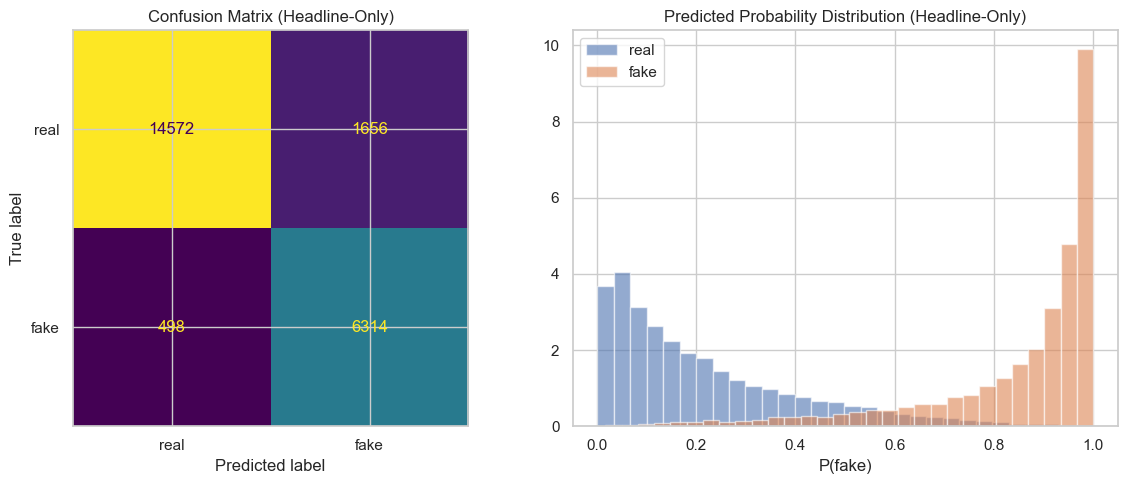

In [80]:
# Headline-only baseline: title text only.
title_train = train_df['title'].astype(str).map(normalize_text)
title_test = test_df['title'].astype(str).map(normalize_text)

headline_word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.98,
    sublinear_tf=True,
    strip_accents='unicode',
    max_features=120000,
)

headline_char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.98,
    sublinear_tf=True,
    max_features=160000,
)

X_train_headline = hstack([
    headline_word_tfidf.fit_transform(title_train),
    headline_char_tfidf.fit_transform(title_train),
]).tocsr()

X_test_headline = hstack([
    headline_word_tfidf.transform(title_test),
    headline_char_tfidf.transform(title_test),
]).tocsr()

headline_clf = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
headline_clf.fit(X_train_headline, y_train)

headline_proba = headline_clf.predict_proba(X_test_headline)[:, 1]
headline_pred = (headline_proba >= 0.50).astype(int)

headline_metrics = {
    'f1': f1_score(y_test, headline_pred, average='binary', pos_label=1),
    'roc_auc': roc_auc_score(y_test, headline_proba),
    'pr_auc': average_precision_score(y_test, headline_proba),
}

print('Headline-only metrics:')
print(f"- F1: {headline_metrics['f1']:.4f}")
print(f"- ROC-AUC: {headline_metrics['roc_auc']:.4f}")
print(f"- PR-AUC: {headline_metrics['pr_auc']:.4f}")

print('\nClassification report (headline-only):')
print(classification_report(y_test, headline_pred, target_names=['real', 'fake']))

if 'linear_metrics' in globals():
    print('\nDelta vs full-text TF-IDF baseline (headline - full-text):')
    print(f"- F1 delta: {headline_metrics['f1'] - linear_metrics['f1']:+.4f}")
    print(f"- ROC-AUC delta: {headline_metrics['roc_auc'] - linear_metrics['roc_auc']:+.4f}")
    print(f"- PR-AUC delta: {headline_metrics['pr_auc'] - linear_metrics['pr_auc']:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, headline_pred)
ConfusionMatrixDisplay(cm, display_labels=['real', 'fake']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Headline-Only)')

axes[1].hist(headline_proba[y_test == 0], bins=30, alpha=0.6, label='real', density=True)
axes[1].hist(headline_proba[y_test == 1], bins=30, alpha=0.6, label='fake', density=True)
axes[1].set_title('Predicted Probability Distribution (Headline-Only)')
axes[1].set_xlabel('P(fake)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 19) Final Comparison Table

Consolidate model results side by side, including the headline-only experiment.


In [81]:
headline_row = {
    'Model': 'TF-IDF + Logistic Regression (Headline-Only)',
    'F1': headline_metrics['f1'] if 'headline_metrics' in globals() else np.nan,
    'ROC-AUC': headline_metrics['roc_auc'] if 'headline_metrics' in globals() else np.nan,
    'PR-AUC': headline_metrics['pr_auc'] if 'headline_metrics' in globals() else np.nan,
}

results = [
    {
        'Model': 'TF-IDF + Logistic Regression',
        'F1': linear_metrics['f1'],
        'ROC-AUC': linear_metrics['roc_auc'],
        'PR-AUC': linear_metrics['pr_auc'],
    },
    headline_row,
    {
        'Model': 'DistilBERT',
        'F1': bert_eval.get('eval_f1', np.nan),
        'ROC-AUC': bert_eval.get('eval_roc_auc', np.nan),
        'PR-AUC': bert_eval.get('eval_pr_auc', np.nan),
    },
    {
        'Model': 'DANN (SVD + MLP)',
        'F1': dann_metrics['f1'],
        'ROC-AUC': dann_metrics['roc_auc'],
        'PR-AUC': dann_metrics['pr_auc'],
    },
]

results_df = pd.DataFrame(results)
results_df



,Model,F1,ROC-AUC,PR-AUC
0,TF-IDF + Logistic Regression,0.901547,0.992308,0.985554
1,TF-IDF + Logistic Regression (Headline-Only),0.854282,0.973032,0.953103
2,DistilBERT,0.994316,0.999787,0.999468
3,DANN (SVD + MLP),0.864847,0.992290,0.985115


## 20) Headline-Only Improvement Goal (DistilBERT + DANN)

A practical next objective is to improve **headline-only** classification, since headlines are often all people read.

This section keeps the same split strategy and tries two stronger headline-only models:
- DistilBERT on titles only
- DANN on title TF-IDF features

Success criterion: beat the headline-only TF-IDF baseline on `F1` while keeping runtime reasonable.


In [82]:
# Headline-only DistilBERT
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

headline_bert_train = train_df[['title', 'label']].copy()
headline_bert_test = test_df[['title', 'label']].copy()

# Keep runtime manageable on CPU while preserving a fair comparison.
headline_bert_train = headline_bert_train.sample(min(len(headline_bert_train), 20000), random_state=RANDOM_STATE)
headline_bert_test = headline_bert_test.sample(min(len(headline_bert_test), 5000), random_state=RANDOM_STATE)

label_map = {'real': 0, 'fake': 1}
headline_bert_train['y'] = headline_bert_train['label'].map(label_map)
headline_bert_test['y'] = headline_bert_test['label'].map(label_map)

headline_train_ds = Dataset.from_pandas(
    headline_bert_train[['title', 'y']].rename(columns={'title': 'text', 'y': 'label'})
)
headline_test_ds = Dataset.from_pandas(
    headline_bert_test[['title', 'y']].rename(columns={'title': 'text', 'y': 'label'})
)

model_name = 'distilbert-base-uncased'
headline_tokenizer = AutoTokenizer.from_pretrained(model_name)

def headline_tokenize_fn(batch):
    return headline_tokenizer(batch['text'], truncation=True, padding='max_length', max_length=64)

headline_train_ds = headline_train_ds.map(headline_tokenize_fn, batched=True)
headline_test_ds = headline_test_ds.map(headline_tokenize_fn, batched=True)
headline_train_ds = headline_train_ds.remove_columns(['text'])
headline_test_ds = headline_test_ds.remove_columns(['text'])
headline_train_ds.set_format('torch')
headline_test_ds.set_format('torch')

headline_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

headline_args_common = dict(
    output_dir=str(BASE_DIR / 'outputs' / 'headline_bert_run'),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    save_strategy='no',
    logging_steps=100,
    report_to='none',
    disable_tqdm=True,
    seed=RANDOM_STATE,
)
try:
    headline_args = TrainingArguments(eval_strategy='epoch', **headline_args_common)
except TypeError:
    headline_args = TrainingArguments(evaluation_strategy='epoch', **headline_args_common)

def headline_bert_compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits)
    labels = np.asarray(labels)
    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp_logits[:, 1] / exp_logits.sum(axis=1)
    preds = (probs >= 0.5).astype(int)
    return {
        'f1': f1_score(labels, preds, average='binary', pos_label=1),
        'roc_auc': roc_auc_score(labels, probs),
        'pr_auc': average_precision_score(labels, probs),
    }

headline_trainer = Trainer(
    model=headline_model,
    args=headline_args,
    train_dataset=headline_train_ds,
    eval_dataset=headline_test_ds,
    compute_metrics=headline_bert_compute_metrics,
)

headline_trainer.train()
headline_bert_eval = headline_trainer.evaluate()
print('Headline DistilBERT metrics:', headline_bert_eval)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5112.51it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/justin/CSC466/Fake-News/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not suppo

{'loss': '0.3522', 'grad_norm': '23.4', 'learning_rate': '1.95e-05', 'epoch': '0.05066'}
{'loss': '0.2146', 'grad_norm': '0.1408', 'learning_rate': '1.899e-05', 'epoch': '0.1013'}
{'loss': '0.1916', 'grad_norm': '50.77', 'learning_rate': '1.849e-05', 'epoch': '0.152'}
{'loss': '0.1725', 'grad_norm': '0.1568', 'learning_rate': '1.798e-05', 'epoch': '0.2026'}
{'loss': '0.1321', 'grad_norm': '0.6854', 'learning_rate': '1.747e-05', 'epoch': '0.2533'}
{'loss': '0.0996', 'grad_norm': '0.2512', 'learning_rate': '1.697e-05', 'epoch': '0.304'}
{'loss': '0.1375', 'grad_norm': '0.1146', 'learning_rate': '1.646e-05', 'epoch': '0.3546'}
{'loss': '0.1491', 'grad_norm': '10.16', 'learning_rate': '1.595e-05', 'epoch': '0.4053'}
{'loss': '0.1719', 'grad_norm': '29.66', 'learning_rate': '1.545e-05', 'epoch': '0.4559'}
{'loss': '0.1108', 'grad_norm': '8.989', 'learning_rate': '1.494e-05', 'epoch': '0.5066'}
{'loss': '0.1739', 'grad_norm': '0.06174', 'learning_rate': '1.443e-05', 'epoch': '0.5572'}
{'loss

/Users/justin/CSC466/Fake-News/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.06941', 'grad_norm': '0.2615', 'learning_rate': '9.873e-06', 'epoch': '1.013'}
{'loss': '0.06833', 'grad_norm': '0.4396', 'learning_rate': '9.367e-06', 'epoch': '1.064'}
{'loss': '0.05018', 'grad_norm': '39.34', 'learning_rate': '8.86e-06', 'epoch': '1.114'}
{'loss': '0.0532', 'grad_norm': '0.0104', 'learning_rate': '8.354e-06', 'epoch': '1.165'}
{'loss': '0.06795', 'grad_norm': '0.3473', 'learning_rate': '7.847e-06', 'epoch': '1.216'}
{'loss': '0.0503', 'grad_norm': '0.008999', 'learning_rate': '7.34e-06', 'epoch': '1.266'}
{'loss': '0.07814', 'grad_norm': '0.009366', 'learning_rate': '6.834e-06', 'epoch': '1.317'}
{'loss': '0.03609', 'grad_norm': '0.006715', 'learning_rate': '6.327e-06', 'epoch': '1.368'}
{'loss': '0.02794', 'grad_norm': '0.01644', 'learning_rate': '5.821e-06', 'epoch': '1.418'}
{'loss': '0.04532', 'grad_norm': '0.006394', 'learning_rate': '5.314e-06', 'epoch': '1.469'}
{'loss': '0.03177', 'grad_norm': '0.3123', 'learning_rate': '4.807e-06', 'epoch': '1.5

/Users/justin/CSC466/Fake-News/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.2234', 'eval_f1': '0.9244', 'eval_roc_auc': '0.9953', 'eval_pr_auc': '0.9922', 'eval_runtime': '13.18', 'eval_samples_per_second': '379.4', 'eval_steps_per_second': '23.75', 'epoch': '2'}
Headline DistilBERT metrics: {'eval_loss': 0.2233838438987732, 'eval_f1': 0.9243910155014236, 'eval_roc_auc': 0.9953209627187403, 'eval_pr_auc': 0.9922404351896594, 'eval_runtime': 13.1779, 'eval_samples_per_second': 379.424, 'eval_steps_per_second': 23.752, 'epoch': 2.0}


In [83]:
# Headline-only DANN (TF-IDF -> SVD -> adversarial head)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

title_train = train_df['title'].astype(str).map(normalize_text)
title_test = test_df['title'].astype(str).map(normalize_text)

headline_word_tfidf_dann = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=3, max_df=0.98,
    sublinear_tf=True, strip_accents='unicode', max_features=120000,
)
headline_char_tfidf_dann = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5), min_df=3, max_df=0.98,
    sublinear_tf=True, max_features=160000,
)

X_train_headline_dann = hstack([
    headline_word_tfidf_dann.fit_transform(title_train),
    headline_char_tfidf_dann.fit_transform(title_train),
]).tocsr()
X_test_headline_dann = hstack([
    headline_word_tfidf_dann.transform(title_test),
    headline_char_tfidf_dann.transform(title_test),
]).tocsr()

headline_svd = TruncatedSVD(n_components=256, random_state=RANDOM_STATE)
X_train_headline_dense = headline_svd.fit_transform(X_train_headline_dann)
X_test_headline_dense = headline_svd.transform(X_test_headline_dann)

headline_scaler = StandardScaler()
X_train_headline_dense = headline_scaler.fit_transform(X_train_headline_dense)
X_test_headline_dense = headline_scaler.transform(X_test_headline_dense)

headline_train_tmp = train_df.copy()
headline_median_year = int(split_df['year'].dropna().median())
headline_train_tmp['domain'] = (headline_train_tmp['year'] > headline_median_year).astype(int)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)
d_train_t = torch.tensor(headline_train_tmp['domain'].values, dtype=torch.long)

X_train_t = torch.tensor(X_train_headline_dense, dtype=torch.float32)
X_test_t = torch.tensor(X_test_headline_dense, dtype=torch.float32)

headline_train_loader = DataLoader(TensorDataset(X_train_t, y_train_t, d_train_t), batch_size=128, shuffle=True)
headline_test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256)

class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lam * grad_output, None

class HeadlineDANN(nn.Module):
    def __init__(self, in_dim=256, hid=128):
        super().__init__()
        self.feature = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Dropout(0.2))
        self.label_head = nn.Linear(hid, 2)
        self.domain_head = nn.Linear(hid, 2)

    def forward(self, x, lam=1.0):
        f = self.feature(x)
        y_logits = self.label_head(f)
        rev_f = GradReverse.apply(f, lam)
        d_logits = self.domain_head(rev_f)
        return y_logits, d_logits

device = 'cuda' if torch.cuda.is_available() else 'cpu'
headline_dann_model = HeadlineDANN().to(device)
headline_opt = torch.optim.Adam(headline_dann_model.parameters(), lr=1e-3)
headline_ce = nn.CrossEntropyLoss()
HEADLINE_DANN_EPOCHS = 8

for epoch in range(1, HEADLINE_DANN_EPOCHS + 1):
    headline_dann_model.train()
    total_loss = 0.0
    for xb, yb, db in headline_train_loader:
        xb, yb, db = xb.to(device), yb.to(device), db.to(device)
        lam = min(1.0, epoch / HEADLINE_DANN_EPOCHS)
        y_logits, d_logits = headline_dann_model(xb, lam=lam)
        loss = headline_ce(y_logits, yb) + 0.5 * headline_ce(d_logits, db)
        headline_opt.zero_grad()
        loss.backward()
        headline_opt.step()
        total_loss += loss.item() * xb.size(0)
    print(f'Epoch {epoch}: loss={total_loss / len(headline_train_loader.dataset):.4f}')

headline_dann_model.eval()
headline_probs, headline_preds = [], []
with torch.no_grad():
    for xb, _ in headline_test_loader:
        xb = xb.to(device)
        y_logits, _ = headline_dann_model(xb, lam=0.0)
        probs = torch.softmax(y_logits, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        headline_probs.extend(probs)
        headline_preds.extend(preds)

headline_dann_metrics = {
    'f1': f1_score(y_test, headline_preds, average='binary', pos_label=1),
    'roc_auc': roc_auc_score(y_test, headline_probs),
    'pr_auc': average_precision_score(y_test, headline_probs),
}
print('Headline DANN metrics:', headline_dann_metrics)


Epoch 1: loss=0.4610
Epoch 2: loss=0.1860
Epoch 3: loss=0.1438
Epoch 4: loss=0.1186
Epoch 5: loss=0.1023
Epoch 6: loss=0.0846
Epoch 7: loss=0.0701
Epoch 8: loss=0.0592
Headline DANN metrics: {'f1': 0.7931888544891641, 'roc_auc': 0.9650509634363288, 'pr_auc': 0.9404224598288832}


In [84]:
# Headline-only model comparison
headline_goal_results = [
    {
        'Model': 'Headline TF-IDF + Logistic Regression',
        'F1': headline_metrics['f1'] if 'headline_metrics' in globals() else np.nan,
        'ROC-AUC': headline_metrics['roc_auc'] if 'headline_metrics' in globals() else np.nan,
        'PR-AUC': headline_metrics['pr_auc'] if 'headline_metrics' in globals() else np.nan,
    },
    {
        'Model': 'Headline DistilBERT',
        'F1': headline_bert_eval.get('eval_f1', np.nan) if 'headline_bert_eval' in globals() else np.nan,
        'ROC-AUC': headline_bert_eval.get('eval_roc_auc', np.nan) if 'headline_bert_eval' in globals() else np.nan,
        'PR-AUC': headline_bert_eval.get('eval_pr_auc', np.nan) if 'headline_bert_eval' in globals() else np.nan,
    },
    {
        'Model': 'Headline DANN (SVD + MLP)',
        'F1': headline_dann_metrics['f1'] if 'headline_dann_metrics' in globals() else np.nan,
        'ROC-AUC': headline_dann_metrics['roc_auc'] if 'headline_dann_metrics' in globals() else np.nan,
        'PR-AUC': headline_dann_metrics['pr_auc'] if 'headline_dann_metrics' in globals() else np.nan,
    },
]

headline_goal_df = pd.DataFrame(headline_goal_results)
headline_goal_df


,Model,F1,ROC-AUC,PR-AUC
0,Headline TF-IDF + Logistic Regression,0.854282,0.973032,0.953103
1,Headline DistilBERT,0.924391,0.995321,0.992240
2,Headline DANN (SVD + MLP),0.793189,0.965051,0.940422


## 21) Interpretation, Metric Meanings, and Summary

`F1` is computed from confusion-matrix counts for the positive class (`fake`): precision is `TP / (TP + FP)`, recall is `TP / (TP + FN)`, and `F1 = 2*TP / (2*TP + FP + FN)`. `ROC-AUC` can be read as the chance a random fake article is scored above a random real article. `PR-AUC` reflects how well precision stays high while recall increases for the fake class.

From the latest runs, full-text DistilBERT remains the strongest overall model (`F1 = 0.9943`, `ROC-AUC = 0.9998`, `PR-AUC = 0.9995`). Full-text TF-IDF + Logistic Regression is still a strong and much cheaper baseline (`F1 = 0.9015`, `ROC-AUC = 0.9923`, `PR-AUC = 0.9856`). Full-text DANN (`F1 = 0.8648`) did not beat the simpler full-text baseline on final classification quality.

For the headline-only objective, the improvement goal was met with DistilBERT: headline DistilBERT (`F1 = 0.9244`, `ROC-AUC = 0.9953`, `PR-AUC = 0.9922`) clearly outperformed headline TF-IDF (`F1 = 0.8543`, `ROC-AUC = 0.9730`, `PR-AUC = 0.9531`). Headline DANN underperformed both (`F1 = 0.7932`, `ROC-AUC = 0.9651`, `PR-AUC = 0.9404`) in the current configuration.

Practically: if you want best quality and can afford runtime, use DistilBERT. If you need fast iteration and lower cost, use TF-IDF + Logistic Regression. A key limitation remains that this dataset appears relatively easy to separate by label, so future data collection should include harder cases (headline-only ambiguity, paraphrases of the same event, mixed-source same-event coverage, and newer topics with weaker lexical cues).
